# ENTSO-E Spot Prices Time Series

This notebook loads the spot prices from `GUI_ENERGY_PRICES_202512312300-202612312300.csv`, parses the time intervals, and visualizes the day-ahead price series.

In [1]:
# Optional: install dependencies in the notebook environment
%pip -q install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
csv_path = Path("GUI_ENERGY_PRICES_202512312300-202612312300.csv")

df = pd.read_csv(csv_path)
df.head()

,MTU (CET/CEST),Area,Sequence,Day-ahead Price (EUR/MWh),Intraday Period (CET/CEST),Intraday Price (EUR/MWh)
0,01/01/2026 00:00:00 - 01/01/2026 00:15:00,BZN|NL,Without Sequence,72.91,NaN,NaN
1,01/01/2026 00:15:00 - 01/01/2026 00:30:00,BZN|NL,Without Sequence,69.16,NaN,NaN
2,01/01/2026 00:30:00 - 01/01/2026 00:45:00,BZN|NL,Without Sequence,59.80,NaN,NaN
3,01/01/2026 00:45:00 - 01/01/2026 01:00:00,BZN|NL,Without Sequence,51.90,NaN,NaN
4,01/01/2026 01:00:00 - 01/01/2026 01:15:00,BZN|NL,Without Sequence,75.66,NaN,NaN


In [4]:
def clean_mtu_part(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace(r"\\s*\\((?:CET|CEST)\\)", "", regex=True)
        .str.strip()
    )

time_parts = df["MTU (CET/CEST)"].str.split(" - ", expand=True)
df["start_time"] = pd.to_datetime(
    clean_mtu_part(time_parts[0]),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)
df["end_time"] = pd.to_datetime(
    clean_mtu_part(time_parts[1]),
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce",
)

df["spot_price_eur_mwh"] = pd.to_numeric(df["Day-ahead Price (EUR/MWh)"], errors="coerce")

prices = (
    df[["start_time", "end_time", "Area", "spot_price_eur_mwh"]]
    .dropna(subset=["start_time", "end_time", "spot_price_eur_mwh"])
    .sort_values("start_time")
    .set_index("start_time")
)

prices.head()

,end_time,Area,spot_price_eur_mwh
start_time,,,
2026-01-01 00:00:00,2026-01-01 00:15:00,BZN|NL,72.91
2026-01-01 00:15:00,2026-01-01 00:30:00,BZN|NL,69.16
2026-01-01 00:30:00,2026-01-01 00:45:00,BZN|NL,59.80
2026-01-01 00:45:00,2026-01-01 01:00:00,BZN|NL,51.90
2026-01-01 01:00:00,2026-01-01 01:15:00,BZN|NL,75.66


In [5]:
summary = pd.Series(
    {
        "rows": len(prices),
        "start": prices.index.min(),
        "end": prices.index.max(),
        "min_price": prices["spot_price_eur_mwh"].min(),
        "max_price": prices["spot_price_eur_mwh"].max(),
        "mean_price": prices["spot_price_eur_mwh"].mean(),
        "median_price": prices["spot_price_eur_mwh"].median(),
    }
)

summary

rows                           8537
start           2026-01-01 00:00:00
end             2026-03-30 23:45:00
min_price                    -17.84
max_price                    449.46
mean_price                 99.80262
median_price                  99.04
dtype: object

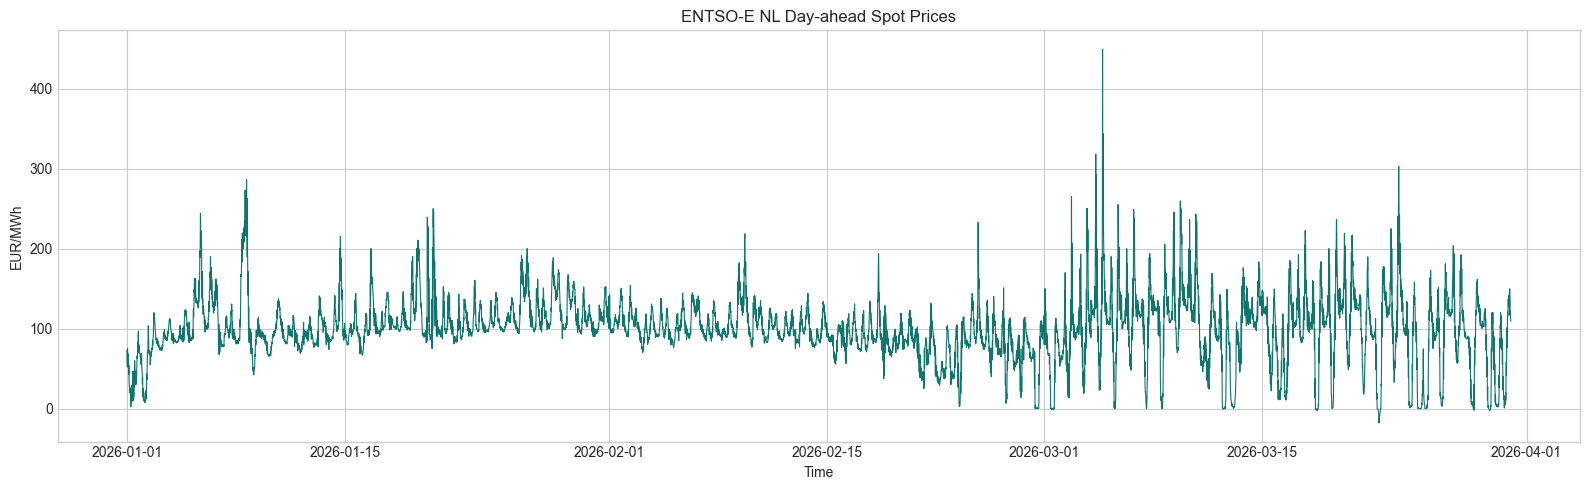

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(prices.index, prices["spot_price_eur_mwh"], linewidth=0.8, color="#0f766e")
ax.set_title("ENTSO-E NL Day-ahead Spot Prices")
ax.set_xlabel("Time")
ax.set_ylabel("EUR/MWh")
plt.tight_layout()
plt.show()

In [7]:
daily = prices["spot_price_eur_mwh"].resample("D").agg(["mean", "min", "max"])
daily.head()

,mean,min,max
start_time,,,
2026-01-01,47.348021,2.34,96.84
2026-01-02,63.197500,7.60,119.98
2026-01-03,88.590521,72.73,112.72
2026-01-04,94.326563,82.19,123.50
2026-01-05,133.592604,82.58,244.39


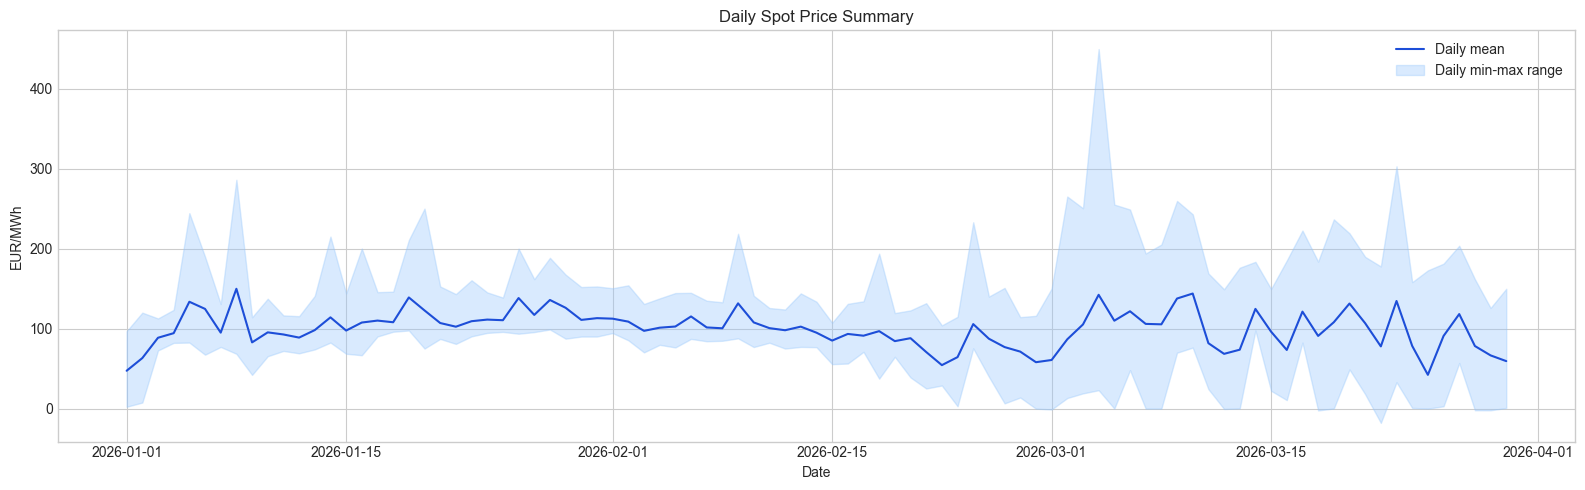

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily.index, daily["mean"], label="Daily mean", color="#1d4ed8", linewidth=1.5)
ax.fill_between(daily.index, daily["min"], daily["max"], color="#93c5fd", alpha=0.35, label="Daily min-max range")
ax.set_title("Daily Spot Price Summary")
ax.set_xlabel("Date")
ax.set_ylabel("EUR/MWh")
ax.legend()
plt.tight_layout()
plt.show()

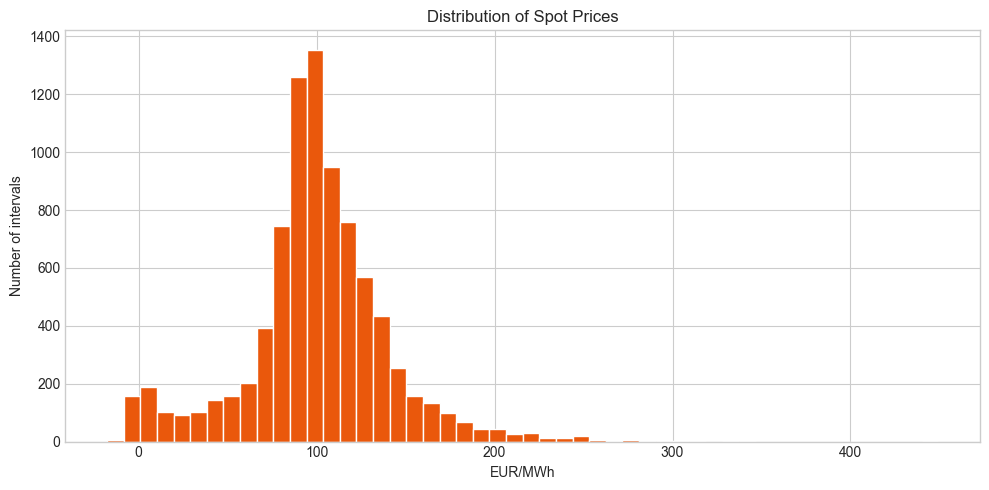

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(prices["spot_price_eur_mwh"], bins=50, color="#ea580c", edgecolor="white")
ax.set_title("Distribution of Spot Prices")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Number of intervals")
plt.tight_layout()
plt.show()